In [60]:
import pandas as pd
import numpy as np
df=pd.read_csv('heart.csv')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125.0,212,0,NaN,168.0,0,1.0,2,2.0,3.0,0
1,53,1,0,140.0,203,1,0.0,155.0,1,3.1,0,0.0,3.0,0
2,70,1,0,145.0,174,0,1.0,125.0,1,2.6,0,0.0,3.0,0
3,61,1,0,148.0,203,0,1.0,NaN,0,0.0,2,1.0,3.0,0
4,62,0,0,138.0,294,1,1.0,106.0,0,1.9,1,3.0,2.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140.0,221,0,1.0,164.0,1,0.0,2,0.0,2.0,1
1021,60,1,0,125.0,258,0,0.0,141.0,1,2.8,1,1.0,3.0,0
1022,47,1,0,110.0,275,0,0.0,118.0,1,1.0,1,1.0,2.0,0
1023,50,0,0,110.0,254,0,0.0,159.0,0,0.0,2,0.0,2.0,1


In [61]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    1
chol        0
fbs         0
restecg     1
thalach     1
exang       0
oldpeak     0
slope       0
ca          2
thal        1
target      0
dtype: int64

In [62]:
df['trestbps']=df['trestbps'].fillna(df['trestbps'].mode()[0])
df['restecg']=df['restecg'].fillna(df['restecg'].mode()[0])
df['thalach']=df['thalach'].fillna(df['thalach'].mode()[0])
df['ca']=df['ca'].fillna(df['ca'].mode()[0])
df['thal']=df['thal'].fillna(df['thal'].mode()[0])

In [63]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [64]:
x=df.drop(columns='target')
x

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125.0,212,0,1.0,168.0,0,1.0,2,2.0,3.0
1,53,1,0,140.0,203,1,0.0,155.0,1,3.1,0,0.0,3.0
2,70,1,0,145.0,174,0,1.0,125.0,1,2.6,0,0.0,3.0
3,61,1,0,148.0,203,0,1.0,162.0,0,0.0,2,1.0,3.0
4,62,0,0,138.0,294,1,1.0,106.0,0,1.9,1,3.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140.0,221,0,1.0,164.0,1,0.0,2,0.0,2.0
1021,60,1,0,125.0,258,0,0.0,141.0,1,2.8,1,1.0,3.0
1022,47,1,0,110.0,275,0,0.0,118.0,1,1.0,1,1.0,2.0
1023,50,0,0,110.0,254,0,0.0,159.0,0,0.0,2,0.0,2.0


In [65]:
y=df['target']
y

0       0
1       0
2       0
3       0
4       0
       ..
1020    1
1021    0
1022    0
1023    1
1024    0
Name: target, Length: 1025, dtype: int64

In [66]:
print(x.ndim)
print(y.ndim)

2
1


In [67]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=0)
print(x_train)
print(y_train)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
491   57    1   2     150.0   168    0      1.0    174.0      0      1.6   
356   59    1   0     164.0   176    1      0.0     90.0      0      1.0   
10    71    0   0     112.0   149    0      1.0    125.0      0      1.6   
105   47    1   0     110.0   275    0      0.0    118.0      1      1.0   
68    37    0   2     120.0   215    0      1.0    170.0      0      0.0   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
835   49    1   2     118.0   149    0      0.0    126.0      0      0.8   
192   67    0   2     115.0   564    0      0.0    160.0      0      1.6   
629   65    1   3     138.0   282    1      0.0    174.0      0      1.4   
559   67    1   0     120.0   237    0      1.0     71.0      0      1.0   
684   60    1   2     140.0   185    0      0.0    155.0      0      3.0   

     slope   ca  thal  
491      2  0.0   2.0  
356      1  2.0   1.0  
10       1  0.0

In [68]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(717, 13)
(308, 13)
(717,)
(308,)


In [69]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(x_train)
scaler.transform(x_train)
scaler.transform(x_test)

array([[-1.16453806,  0.65226323,  1.02564169, ...,  0.9790949 ,
        -0.73603133, -0.51108759],
       [ 0.38807624, -1.53312338,  0.05419507, ...,  0.9790949 ,
         1.21132832, -0.51108759],
       [ 0.94258134,  0.65226323, -0.91725155, ...,  0.9790949 ,
         1.21132832,  1.10322872],
       ...,
       [ 0.16627419,  0.65226323,  1.02564169, ..., -0.66111782,
         0.23764849, -2.12540389],
       [ 0.27717522, -1.53312338, -0.91725155, ...,  0.9790949 ,
        -0.73603133, -0.51108759],
       [-0.05552785,  0.65226323, -0.91725155, ..., -0.66111782,
         0.23764849,  1.10322872]])

In [70]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()
knn.fit(x_train,y_train)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [71]:
y_pred=knn.predict(x_test)

In [72]:
from sklearn.metrics import accuracy_score,ConfusionMatrixDisplay,confusion_matrix
cm=confusion_matrix(y_pred,y_test)
a=accuracy_score(y_pred,y_test)
a

0.7435064935064936

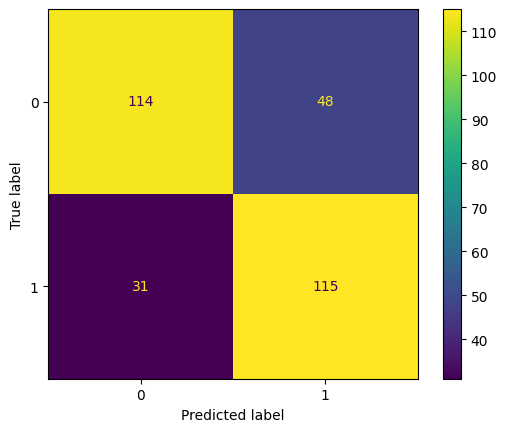

In [73]:
c=ConfusionMatrixDisplay(cm)
c.plot()

In [74]:
from sklearn.model_selection import GridSearchCV
model1=KNeighborsClassifier()
data={'n_neighbors':[3,5,7,9,11],'weights':['uniform','distance']}
clf=GridSearchCV(model1,data,cv=10,scoring='accuracy')
clf.fit(x_train,y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,7


In [75]:
print(clf.best_params_)

{'n_neighbors': 7, 'weights': 'distance'}


In [76]:
model2=KNeighborsClassifier(n_neighbors=7,weights='distance')
model2.fit(x_train,y_train)
y_pred1=model2.predict(x_test)
y_pred1

array([1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,

In [77]:
acc1=accuracy_score(y_pred1,y_test)
acc1

0.9772727272727273